Import Thư viện

In [63]:
import numpy as np
import matplotlib.pyplot as plt 

## Bài 1

Tạo không gian giá trị

In [64]:
Data = ["Tôi là học sinh lớp 5", 
             "Ai thông minh hơn học sinh lớp 5", 
             "Tại sao nhất VMO lại không phải học sinh lớp 5", 
             "Tôi đang đọc sách của Jeffery Deaver", 
             "Sách của Jeffery Deaver đọc rất khó hiểu", 
             "Mỗi ngày tôi đều cố gắng học thêm một điều mới để hoàn thiện bản thân",
             "Đọc sách giúp mở rộng vốn từ vựng và tư duy logic",
             "Thuật toán này cần được tối ưu hóa hơn nữa để chạy nhanh hơn",
             "Cuối tuần này tôi sẽ dành thời gian nghỉ ngơi và đi dạo công viên"]

Vocabulary = list({word for sentence in Data for word in sentence.lower().strip().split()})
Vocabulary.sort()


### 1. Biến dữ liệu thành ma trận

In [65]:
def to_vector(sentence):
    v = np.zeros(len(Vocabulary))
    for word in sentence.lower().split():
        if word in Vocabulary:
            v[Vocabulary.index(word)] += 1
    return v

X = np.array([to_vector(sentence) for sentence in Data])
X

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
 

### 2. Phép toán cơ bản

In [66]:
mean_vec = np.mean(X, axis = 0)
print("Kích thước X ban đầu: ", X.shape)
print("Kích thước của mean_vec: ", mean_vec.shape)
print("Kích thước trung bình cột: \n", mean_vec)
print("Kích thước sau khi trừ giá trị trung bình: ", X.shape)

Kích thước X ban đầu:  (9, 73)
Kích thước của mean_vec:  (73,)
Kích thước trung bình cột: 
 [0.33333333 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.22222222 0.22222222 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.33333333 0.44444444 0.22222222 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.33333333 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.22222222 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.33333333 0.33333333 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.44444444 0.11111111 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.22222222 0.11111111 0.11111111 0.11111111
 0.11111111 0.11111111 0.11111111 0.11111111 0.22222222 0.33333333
 0.11111111]
Kích thước sau khi trừ giá trị trung bình:  (9, 73)


Numpy sẽ so khớp số chiều của hai đối tượng khi thực hiện phép tính (theo chiều từ phải sang trái), và tự dộng nhân bản mean_vec thành ma trận (9, 73) để thực hiện phép tính tương ứng ở từng phần tử.

### 3. Cosine Similarity

In [67]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X 
    X_norm = np.linalg.norm(X, axis=1, keepdims=True) 
    Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)  
    
    Xn = X / X_norm
    Yn = Y / Y_norm
    return Xn @ Yn.T 

sim_matrix = cosine_similarity(X)

### 4. Truy vấn

In [68]:
def search(query, top_k = 3):
    query_vector = to_vector(query)
    
    if np.sum(query_vector) == 0:
        print("Không có từ khớp với query trong từ điển hiện tại!")
        return
    
    query_vector = query_vector.reshape(1, -1)
    
    #Tính cs của query với các câu trong tập Data
    scores = cosine_similarity(X, query_vector).flatten() 
    
    top_index = np.argsort(scores)[::-1][:top_k]
    
    print("Kết quả tìm kiếm của query:")
    print(top_index)
    for i, idx in enumerate(top_index):
        print(f"Top {i + 1}: Câu {idx} - Score: {scores[idx]:.4f} -> {Data[idx]}")
        
search("tôi đi học lập trình", 3)
    

Kết quả tìm kiếm của query:
[0 8 5]
Top 1: Câu 0 - Score: 0.4714 -> Tôi là học sinh lớp 5
Top 2: Câu 8 - Score: 0.2981 -> Cuối tuần này tôi sẽ dành thời gian nghỉ ngơi và đi dạo công viên
Top 3: Câu 5 - Score: 0.2887 -> Mỗi ngày tôi đều cố gắng học thêm một điều mới để hoàn thiện bản thân


### 5. Nhận xét:

Tạo ma trận tương đồng

In [69]:

min_idx = np.unravel_index(np.argmin(sim_matrix), sim_matrix.shape) 
np.fill_diagonal(sim_matrix, -1)
max_idx = np.unravel_index(np.argmax(sim_matrix), sim_matrix.shape)


print(f"Cặp giống nhau nhất: Câu {max_idx[0]} và Câu {max_idx[1]} (Score: {sim_matrix[max_idx]:.4f})")
print(f"  - '{Data[max_idx[0]]}'")
print(f"  - '{Data[max_idx[1]]}'")

print(f"\nCặp khác biệt nhất: Câu {min_idx[0]} và Câu {min_idx[1]} (Score: {sim_matrix[min_idx]:.4f})")
print(f"  - '{Data[min_idx[0]]}'")
print(f"  - '{Data[min_idx[1]]}'")

Cặp giống nhau nhất: Câu 3 và Câu 4 (Score: 0.6682)
  - 'Tôi đang đọc sách của Jeffery Deaver'
  - 'Sách của Jeffery Deaver đọc rất khó hiểu'

Cặp khác biệt nhất: Câu 0 và Câu 4 (Score: 0.0000)
  - 'Tôi là học sinh lớp 5'
  - 'Sách của Jeffery Deaver đọc rất khó hiểu'


1. Cặp giống nhau:
Đúng. Do tính sự tương đồng dựa trên tần suất của từ trong câu, nên kết quả này khớp vì có tới 5 từ trùng lặp là: "đọc", "sách", "của", "jeffery", "deaver". và dựa về mặt ngữ nghĩa thì hai câu này cũng liên quan tới nhau khi đều nhắc tới sách của Jeffery Deaver.

2. Cặp khác nhau:
Đúng. Về mặt ngữ nghĩa câu 0 nói về nhân xưng và trường lớp, trong khi Câu 7 nói về tối ưu thuật toán. Vì hai câu giao nhau ở một từ nào trong không gian vector nên Cosine Similarity trả về đúng 0.0.

## Bài 2

In [70]:
Xc = X - X.mean(axis=0)   
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2]  

print("Kích thước ma trận tọa độ coords:", coords.shape) 

Kích thước ma trận tọa độ coords: (9, 2)


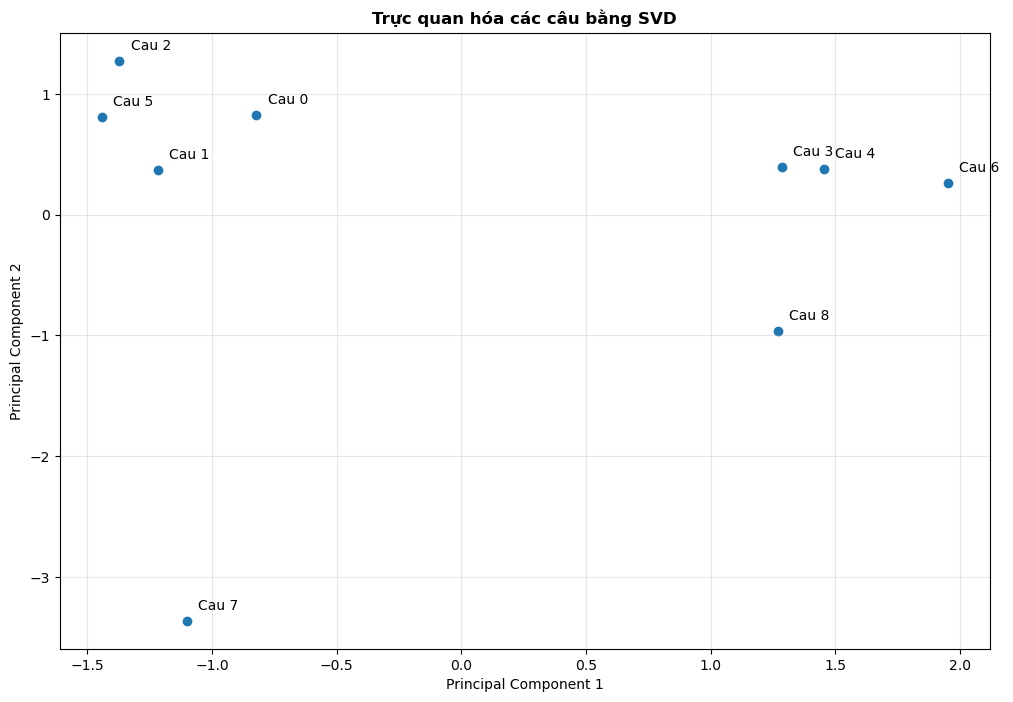

In [90]:
plt.figure(figsize = (12, 8))

plt.scatter(coords[:, 0], coords[:, 1])

for i in range(len(coords)):
    x_coord, y_coord = coords[i]
    sentence_label = f"Cau {i} "
    plt.annotate(sentence_label, 
                 (x_coord, y_coord),
                 textcoords="offset points", 
                 xytext=(8, 8),  
                 ha='left', 
                 fontsize=10)

plt.title("Trực quan hóa các câu bằng SVD", fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.show()

**Các câu nằm cùng chủ đề thì có gần nhau không?**
- Có. Xu hướng phân cụm rất rõ trên đồ thị:
    - Cụm 1 (Câu 0, 1, 2): Các câu liên quan đến "học sinh lớp 5" sẽ nằm tụm lại rất gần nhau ở một khu vực.
    - Cụm 2 (Câu 3, 4): Các câu nói về sách của "Jeffery Deaver" sẽ dính sát lấy nhau.
    - Cụm 3 (Các câu còn lại): Các câu mang chủ đề khác sẽ phân tán rải rác hoặc nằm ở các góc khác của mặt phẳng.

**Liên hệ với eigen/PCA và "trục chính" của dữ liệu.**
- PCA chính là SVD: Việc trừ đi trung bình rồi áp dụng SV lên Xc về bản chất có thể xem là tương đương với PCA.
- Trục chính (Eigenvectors): Ma trận $V^T$ chứa các eigenvector. Mỗi eigenvector đóng vai trò là một "trục chính", đại diện cho một chủ đề ẩn của tập văn bản, hay phương sai của tập dữ liệu.
- Tối ưu thông tin: Tọa độ 2D ta tính được là hình chiếu của dữ liệu lên 2 trục chính lớn nhất (tương ứng với 2 giá trị $S$, hay eigenvalue, lớn nhất). Giúp ta nén không gian dữ liệu xuống mặt phẳng 2D mà vẫn giữ lại được hầu hết các đặc trưng ngữ nghĩa quan trọng nhất.